In [61]:
import torch
import json
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from minisom import MiniSom
import plotly.express as px
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr, kendalltau

In [62]:
def json_to_pyg_data(json_data):
    items = json_data["network"]["items"]
    links = json_data["network"]["links"]

    id_map = {node["id"]: i for i, node in enumerate(items)}

    node_features = []
    for node in items:
        features = [
            node["weights"].get("WoS Categories", 0),
            node["weights"].get("Document Types",  0),
            node["weights"].get("Documents,",0),
            node["scores"].get("Ave. citations",0.0),
            node["scores"].get("Ave. authorships",0.0),
            node["scores"].get("Ave. references",0.0),
            node["scores"].get("Percent of documents",0.0),
            node["scores"].get("Percent of documents Int. Coll.",0.0)
        ]
        node_features.append(features)
    
    #x = torch.tensor(node_features, dtype=torch.float)
    features_array = np.array(node_features, dtype=float)

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_array)
    x = torch.tensor(features_scaled, dtype=torch.float)

    #Aristas
    sources = []
    targets = []
    edge_weights = []
    
    for link in links:
        u_str = link["source_id"]
        v_str = link["target_id"]
        strength = link["strength"]

        u = id_map[u_str]
        v = id_map[v_str]

        sources.append(u)
        targets.append(v)
        edge_weights.append(strength)


    edge_index = torch.tensor([sources, targets], dtype = torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).view(-1,1) #al ser de una sola dimensión, lo pasamos a una matriz de x filas por 1 columna


    #El tipo "Data" es exclusivamente para que sage pueda procesar el grafo
    data = Data(x=x, edge_index = edge_index, edge_attr = edge_attr)
    #x son mis caracteristicas
    #edge_index es la topologia (aristas)
    #edge_attr en este caso son únicamente los pesos

    return data

In [63]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)

snapshot_2003 = json_to_pyg_data(raw_json)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 8], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 8


In [64]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cpu


In [65]:
class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x  # embeddings finales

In [66]:
in_channels = data.num_node_features   # En nuestro caso son 8 features
hidden_channels = 32
out_channels = 16   # dimensión del embedding final

model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [67]:

def get_link_logits(z, edge_index):
    # z: [N, d]
    src, dst = edge_index
    # producto punto entre embeddings de los extremos
    # Si dos vectores apuntan a la misma direccion (son similares) entonces tendrán un valor positivo, en caso contrario
    return (z[src] * z[dst]).sum(dim=-1)  # [num_edges]

def train_linkpred(model, data, epochs=200):
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        # aristas  positivas (reales)
        pos_edge_index = data.edge_index
        # aristas negativas
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1),  # mismo número que positivas
            method="sparse"
        )
        # Logits para positivas y negativas
        pos_logits = get_link_logits(z, pos_edge_index)
        neg_logits = get_link_logits(z, neg_edge_index)
        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat([
            torch.ones(pos_logits.size(0), device=device),
            torch.zeros(neg_logits.size(0), device=device)
        ], dim=0)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    return model

In [68]:
trained_model = train_linkpred(model, data, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 1.0853
Epoch 020 | Loss: 0.4285
Epoch 040 | Loss: 0.4030
Epoch 060 | Loss: 0.3716
Epoch 080 | Loss: 0.3839
Epoch 100 | Loss: 0.3880
Epoch 120 | Loss: 0.4061
Epoch 140 | Loss: 0.3692
Epoch 160 | Loss: 0.3632
Epoch 180 | Loss: 0.3751
Epoch 200 | Loss: 0.3651
dimension de embeddings: (397, 16)
[  5.788593  -16.559423   -7.472419   -3.8849568  -2.6634727  -2.4575083
   7.052803    5.7810516   6.5858665  -5.3953    -16.680304    6.459988
   9.792641  -12.623878   13.901444  -13.463185 ]


In [69]:
# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

torch.Size([397, 16])
Dimension del embedding del grafo: torch.Size([1, 16])
tensor([[ 0.0644, -0.1219, -0.0582, -0.0401, -0.0124, -0.0226,  0.0531,  0.0691,
          0.0614, -0.0392, -0.1005,  0.0497,  0.1014, -0.0858,  0.0952, -0.1096]])


In [70]:
PRESERVAR_HISTORIA = False
START_YEAR = 1980
END_YEAR = 2024
DATA_FOLDER = "./Data/SOM"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


if PRESERVAR_HISTORIA:
    model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    print("Modo: con memoria")
else:
    print("Modo: Sin memoria")
# lilsta de eembeddings de cada año
historia = []

for year in range(START_YEAR, END_YEAR + 1):
    file_path = os.path.join(DATA_FOLDER, f"network_{year}.json")
    
    # Verificar si el archivo existe 
    # El de 1990 no está en la plataforma del c3
    if not os.path.exists(file_path):
        print(f"Saltando {year}: Archivo no encontrado.")
        continue
        
    try:
        with open(file_path, "r") as f:
            raw_json = json.load(f)
        
        data = json_to_pyg_data(raw_json)
        data = data.to(device)

        if not PRESERVAR_HISTORIA:
            model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device) #reseteamos al modelo anterior y creamos uno nuevo
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4) #renovar el optimizador para el nuevo modelo

        
        # Entrenar el modelo con el año actual
        # No se pierde la información del año anterior si no se reseteo el modelo
        model = train_linkpred(model, data, epochs=50) 
        
        #Embeddings de Nodos
        model.eval()
        with torch.no_grad():
            z_nodes = model(data.x, data.edge_index)
            
            # pooling para hacer un solo embedding de un snapshot
            batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
            graph_embedding = global_mean_pool(z_nodes, batch) # Shape: [1, 16]
            
            # Guardar el resultado
            historia.append({
                "year": year,
                "vector": graph_embedding.cpu().numpy()[0] # Convertir a array plano
            })
            
        print(f"{year} procesado.")
        
    except Exception as e:
        print(f"Error en {year}: {e}")

print(f"Se generaron {len(historia)} puntos.")

Modo: Sin memoria
Epoch 001 | Loss: 0.6915
Epoch 020 | Loss: 0.4876
Epoch 040 | Loss: 0.4331
1980 procesado.
Epoch 001 | Loss: 0.9401
Epoch 020 | Loss: 0.4943
Epoch 040 | Loss: 0.4851
1981 procesado.
Epoch 001 | Loss: 0.8573
Epoch 020 | Loss: 0.4625
Epoch 040 | Loss: 0.4361
1982 procesado.
Epoch 001 | Loss: 0.7202
Epoch 020 | Loss: 0.5886
Epoch 040 | Loss: 0.4931
1983 procesado.
Epoch 001 | Loss: 0.7749
Epoch 020 | Loss: 0.5209
Epoch 040 | Loss: 0.4302
1984 procesado.
Epoch 001 | Loss: 0.7170
Epoch 020 | Loss: 0.4941
Epoch 040 | Loss: 0.5538
1985 procesado.
Epoch 001 | Loss: 0.7003
Epoch 020 | Loss: 0.4920
Epoch 040 | Loss: 0.4516
1986 procesado.
Epoch 001 | Loss: 0.6467
Epoch 020 | Loss: 0.4313
Epoch 040 | Loss: 0.4138
1987 procesado.
Epoch 001 | Loss: 0.5624
Epoch 020 | Loss: 0.4244
Epoch 040 | Loss: 0.4448
1988 procesado.
Epoch 001 | Loss: 0.7240
Epoch 020 | Loss: 0.4979
Epoch 040 | Loss: 0.4299
1989 procesado.
Epoch 001 | Loss: 0.8807
Epoch 020 | Loss: 0.4922
Epoch 040 | Loss: 0.49

In [71]:
print(graph_embedding.shape)

torch.Size([1, 16])


In [72]:

vectores = np.array([item["vector"] for item in historia]) #array que contiene los vectores de cada año
years = [item["year"] for item in historia] #para reetiquetar los puntos de acuerdo a su año

# Reducir a 2D
pca = PCA(n_components=2) #Aplanar las 16 mensiones de cada embedding (out_channels=16) a unicamente 2 (coordenadas x,y)
pca_result = pca.fit_transform(vectores) #hacemos uso del algoritmo de pca

# DataFrame para poder graficarlo por medio de Plotly
df_trayectoria = pd.DataFrame({
    'x': pca_result[:, 0], #Todas las filas, pero solo la columna 0, es decir, el eje x
    'y': pca_result[:, 1], #Todas las filas, pero solo la columna 1, es decir, el eje y
    'year': years,
    'label': [str(y) for y in years] 
})

#Graficar la Trayectoria
fig = px.scatter(df_trayectoria, x='x', y='y', 
                 text='label', 
                 color='year',
                 title="Evolución")

# líneas para conectar los puntos
fig.update_traces(mode='lines+markers+text', textposition='top center')

fig.show()

In [73]:


vectores = np.array([item["vector"] for item in historia])
years = [item["year"] for item in historia]

pca_1d = PCA(n_components=1)
coord_y_original = pca_1d.fit_transform(vectores).flatten()

df_flujo = pd.DataFrame({
    'year': years,
    'y_original': coord_y_original
})

# Grafico de linea
fig = px.line(
    df_flujo, 
    x='year', 
    y='y_original',
    title="Evolucion",
    labels={'y_original': 'PC1', 'year': 'Año'},
    markers=True, # ñuntos de cada año
    template="plotly_white"
)

#fig.update_traces(line_shape='spline', line_width=4) #esto es unicamente para "suavizar las esquinas"
fig.show()

Promedios anuales

--- Resultados de Correlación con el Eje Y PC1
WoS Categories: 0.2085
Document Types: 0.0790
Documents,: 0.3155
Ave. citations: 0.0725
Ave. authorships: 0.0464
Ave. references: -0.3205
Percent of documents: -0.0731
Percent of documents Int. Coll.: 0.1222


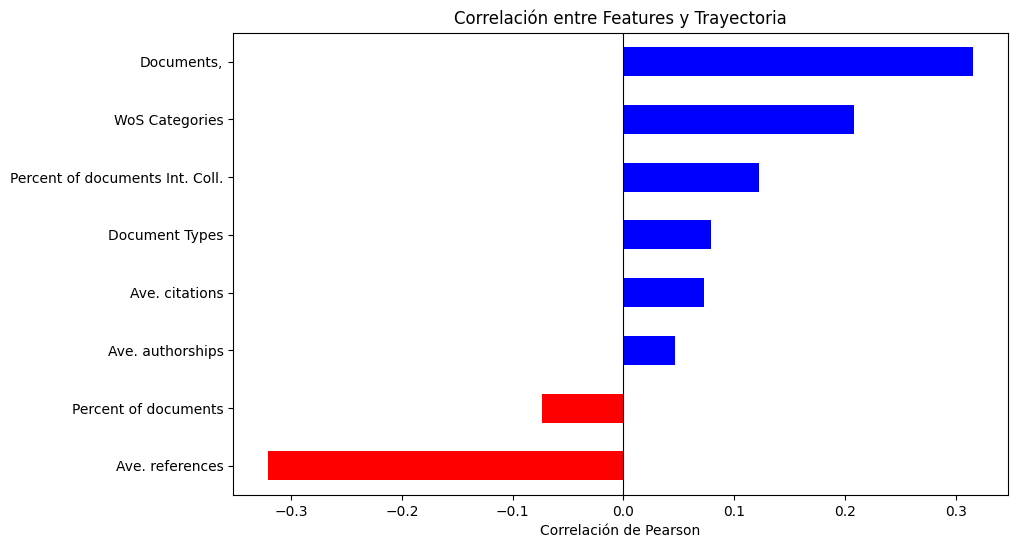

In [74]:
# Correlación de pearson dice qué tan fuerte es la relación lineal entre dos variables
# Cuando la variable A sube, ¿ldf_flujoa variable B también sube proporcionalmente?
trayectoria_y = df_flujo['y_original'].values
years = df_flujo['year'].values

feature_names = [
    "WoS Categories", "Document Types", "Documents,", 
    "Ave. citations", "Ave. authorships", "Ave. references", 
    "Percent of documents", "Percent of documents Int. Coll."
]

# Matriz para guardar el promedio de cada feature por año
# Tamaño: [num_años, num_features]
features_anuales = []

print("Promedios anuales")
#¿Por qué es necesario hacer un promedio?
#Para poder ocupar la correlacion de pearson, debemos de comparar los 45 puntos resultantes del pca con otros 45 puntos.
#(La comparación es 1 a 1 por cada feature, es decir, fijamos un feature y lo comparamos con los 45 tiempos)
#Sin embargo, cada año tiene cierta cantidad de nodos, es necesario obtener un solo valor a partir de todos estos.
#por eso se realiza un promedio

#Para cada año (cada json definido en la carpeta Data_Json)
#Para cada feature (feature_names)
#Añadimos el valor de ese feature de cada nodo a la lista "vals"
#al finalizar de contabilizar este feature, realizamos un promedio y lo agregamos a feats_year
#continuamos con el siguiente feature, continuamos cn el siguiente año hasta terminar
for year in years:
    with open(f"./Data/SOM/network_{year}.json", "r") as f:
        raw_json = json.load(f)

    items = raw_json["network"]["items"]
    feats_year = []
    for feature in feature_names:
        # Extraer el valor de cada nodo
        vals = []
        for node in items:
            val = node.get("weights", {}).get(feature) or node.get("scores", {}).get(feature, 0)
            vals.append(val)
        # Guardar el promedio de este año
        feats_year.append(np.mean(vals))
    
    features_anuales.append(feats_year) #cada fila es un año, y 8 columnas, cada una es el promedio de toda la grafica de un solo feature

df_features = pd.DataFrame(features_anuales, columns=feature_names, index=years)


#Ya tenemos los datos como queremos, podemos proceder a realizar correlacion
#Lista A (Trayectoria generada por pca): 45 valores.
#Lista B (Promedio de cada feature): 45 valores.


correlaciones = {}

print("\n--- Resultados de Correlación con el Eje Y PC1")
for col in df_features.columns:
    # Correlación de Pearson (r),  rango entre [-1,1], sí se acerca a 1 positivo, hay bastante correlación
    r, p_value = pearsonr(trayectoria_y, df_features[col].values) #aqui ya están los 45 años y 45 promedios de cada feature
    correlaciones[col] = r
    print(f"{col}: {r:.4f}")

# Con los valores basta, pero para tener una mejor visualización:
plt.figure(figsize=(10, 6))
sorted_corr = pd.Series(correlaciones).sort_values()# los más importantes primero
colors = ['red' if x < 0 else 'blue' for x in sorted_corr]
sorted_corr.plot(kind='barh', color=colors)
plt.title("Correlación entre Features y Trayectoria")
plt.xlabel("Correlación de Pearson")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [75]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        4.592593        1.666667    5.814815       25.018519   
1981        3.687500        1.500000    5.296875       26.009219   
1982        4.779661        1.525424    6.593220       86.254407   
1983        4.138889        1.444444    5.750000       47.642222   
1984        3.739130        1.500000    5.413043       38.248913   
1985        4.294118        1.529412    7.264706       29.074706   
1986        5.578947        1.526316   11.684211       23.662632   
1987        5.435540        1.843206    8.094077       41.162613   
1988        4.596899        1.627907    4.689922       39.926279   
1989        3.741935        1.435484    4.790323       20.731452   
1990        4.523256        1.546512    4.883721       41.865000   
1991        5.428571        1.816327    8.408163       26.337388   
1992        5.284444        1.715556    7.280000       30.240400   
1993        4.115385        1.576923    5.923077

In [76]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
atributo_a_graficar = "Percent of documents"
#datos que calculamos en el paso anterior (df_features)
df_plot = df_features.reset_index().rename(columns={'index': 'Year'})
fig = px.line(
    df_plot, 
    x='Year', 
    y=atributo_a_graficar,
    title=f"Evolución de: {atributo_a_graficar}",
    markers=True,
    template="plotly_white"
)

# esto es solo para suavisar las esquinas
#fig.update_traces(line_shape='spline', line_width=3)
fig.show()

In [77]:


# Unir las tablas 
# Usamos 'inner' para quedarnos solo con los años que existen en ambos lados
df_comparacion = pd.merge(df_plot, df_flujo, left_on='Year', right_on='year', how='inner')

# Normalización Manual (Escala 0 a 1)
# Para poder comparar directamente las tendencias
#PD es percent of documents

#Por cada atributo definido, se busca al maximo, y a cada valor (fila) es dividido entre ese valor
df_comparacion['PD Crudos'] = df_comparacion['Percent of documents'] / df_comparacion['Percent of documents'].max()
df_comparacion['PD PCA'] = df_comparacion['y_original'] / df_comparacion['y_original'].max()
df_comparacion['Autores'] = df_comparacion['Ave. authorships'] / df_comparacion['Ave. authorships'].max()
# Graficar
fig = px.line(
    df_comparacion, 
    x='Year', 
    y=['PD Crudos', 'PD PCA', 'Autores'], 
    title="Comparación de evoluciónes de los embeddings contra los datos crudos",
    labels={'value': 'Intensidad Relativa (0-1)', 'variable': 'Curva', 'Year': 'Año'},
    template="plotly_white",
    markers=False
)

fig.update_traces(line=dict(width=3)) 
fig.update_traces(patch={"line": {"dash": "dot"}}, selector={"name": "Autores"})
fig.update_traces(patch={"line": {"dash": "dot"}}, selector={"name": "PD Crudos"})
fig.show()

Entrenando SOM...
SOM entrenado.


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not ['61', '2', '4', '2', '2', '1', '3', '4', '3', '3', '3', '7', '9', '7', '7', '3', '1', '4', '6', '7', '6', '1', '2', '7', '1', '6', '4', '1', '2', '1', '3', '6', '2', '2', '3', '3', '1', '3', '2', '2', '7', '7', '4', '7', '4', '3', '3', '3', '2', '3', '1', '4']

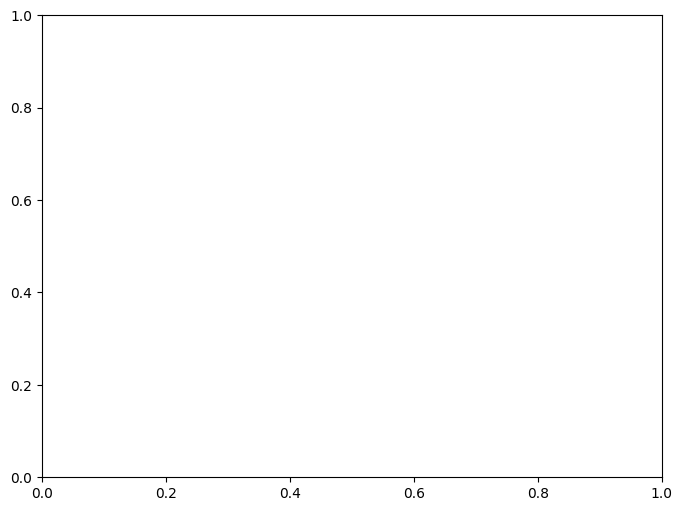

In [78]:

num_nodes, d = embeddings.shape # embeddings := (num_nodes, d)

# Mapa SOM de 10x10
som_x, som_y = 5, 5

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=d,
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)

# Inicializar pesos 
som.random_weights_init(embeddings)
print("Entrenando SOM...")
som.train_random(embeddings, num_iteration=1000)
print("SOM entrenado.")

# Proyectar cada embedding al nodo ganador del SOM
items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]

som_coords_x = []
som_coords_y = []

for v in embeddings:
    i, j = som.winner(v)  # coordenadas (fila, columna) en la rejilla
    som_coords_x.append(i)
    som_coords_y.append(j)

som_coords_x = np.array(som_coords_x, dtype=float)
som_coords_y = np.array(som_coords_y, dtype=float)


jitter = 0.1 # "jitter" para que los puntos no se sobrepongan exactamente
som_coords_x = som_coords_x + np.random.uniform(-jitter, jitter, size=num_nodes)
som_coords_y = som_coords_y + np.random.uniform(-jitter, jitter, size=num_nodes)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(som_coords_x, som_coords_y, c=clusters, s=20, alpha=0.5)
plt.title("Embeddings GraphSAGE proyectados con SOM (2D)")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.colorbar(scatter, label="cluster")
#plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()





In [188]:


# DataFrame con todo los datos
df_vis = pd.DataFrame({
    'x': som_coords_x,
    'y': som_coords_y,
    'label': [node["label"] for node in items],  # Nombres para el mouse
    'cluster': [str(c) for c in clusters],       # Convertir a string 
    'docs': [node["weights"]["Documents"] for node in items] # Tamaño por documentos 
})

# gráfica interactiva
fig = px.scatter(
    df_vis, 
    x='x', 
    y='y', 
    color='cluster',
    hover_name='label',
    size='docs',
    title="Mapa Interactivo de Micro-Tópicos",
    template="plotly_white"
)

fig.show()

ValueError: All arrays must be of the same length